<a href="https://colab.research.google.com/github/AhmedAly74/NHA-4-14/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ربط Google Drive
from google.colab import drive
drive.mount('/content/drive')

# تحديد مسار الداتا مباشرة
DATASET_PATH = "/content/drive/MyDrive"

TRAIN_IMAGES = f"{DATASET_PATH}/train/images"
TRAIN_LABELS = f"{DATASET_PATH}/train/labels"

print("Paths Ready ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths Ready ✅


In [10]:
from pathlib import Path

print("Images:", len(list(Path(TRAIN_IMAGES).glob("*"))))
print("Labels:", len(list(Path(TRAIN_LABELS).glob("*.txt"))))

Images: 11005
Labels: 11005


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

In [13]:
# Check Dataset Structure
import os

for folder in os.listdir("/content/drive/MyDrive"):
    print(folder)

data.yaml
README.roboflow.txt
train


In [14]:
#  Count Images and Labels
total_images = len(list(Path(TRAIN_IMAGES).glob("*")))
total_labels = len(list(Path(TRAIN_LABELS).glob("*.txt")))

print(f"Total Images : {total_images}")
print(f"Total Labels : {total_labels}")

Total Images : 11005
Total Labels : 11005


In [15]:
# Load Class Names
import yaml

with open("/content/drive/MyDrive/data.yaml") as f:
    data = yaml.safe_load(f)

CLASS_NAMES = data['names']
print("Classes:", CLASS_NAMES)

Classes: ['Bus', 'Cyclist', 'Light Vehicle', 'Long Truck', 'Medium Truck', 'Minibus Taxi', 'Motorcycle', 'Pedestrian', 'Person with wheel barrow', 'Short Truck']


In [17]:
# Parse Labels into DataFrame
records = []

for label_file in Path(TRAIN_LABELS).glob("*.txt"):
    with open(label_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, x, y, w, h = parts
                records.append({
                    "filename": label_file.stem,
                    "class_id": int(class_id),
                    "class_name": CLASS_NAMES[int(class_id)],
                    "x_center": float(x),
                    "y_center": float(y),
                    "width": float(w),
                    "height": float(h),
                    "bbox_area": float(w) * float(h)
                })

df = pd.DataFrame(records)

print(f"Total objects found: {len(df)}")
df.head(10)

Total objects found: 40776


,filename,class_id,class_name,x_center,y_center,width,height,bbox_area
0,20254_png.rf.52488a8997e8e1033972f1f69822b082,2,Light Vehicle,0.464062,0.667969,0.082031,0.096094,0.007883
1,20254_png.rf.52488a8997e8e1033972f1f69822b082,5,Minibus Taxi,0.882031,0.758594,0.235937,0.292969,0.069122
2,20254_png.rf.52488a8997e8e1033972f1f69822b082,9,Short Truck,0.560156,0.545312,0.163281,0.107813,0.017604
3,20254_png.rf.52488a8997e8e1033972f1f69822b082,7,Pedestrian,0.792969,0.798438,0.053125,0.175781,0.009338
4,20253_png.rf.93b6ab927d616595e2e088773d8a661f,2,Light Vehicle,0.497656,0.610938,0.071875,0.086719,0.006233
5,20253_png.rf.93b6ab927d616595e2e088773d8a661f,2,Light Vehicle,0.460156,0.667969,0.079687,0.096094,0.007657
6,20253_png.rf.93b6ab927d616595e2e088773d8a661f,5,Minibus Taxi,0.880469,0.755469,0.239063,0.292187,0.069851
7,20253_png.rf.93b6ab927d616595e2e088773d8a661f,7,Pedestrian,0.587500,0.667969,0.033594,0.100781,0.003386
8,20253_png.rf.93b6ab927d616595e2e088773d8a661f,7,Pedestrian,0.678125,0.937500,0.076563,0.122656,0.009391
9,20253_png.rf.93b6ab927d616595e2e088773d8a661f,2,Light Vehicle,0.714844,0.680469,0.146875,0.139063,0.020425


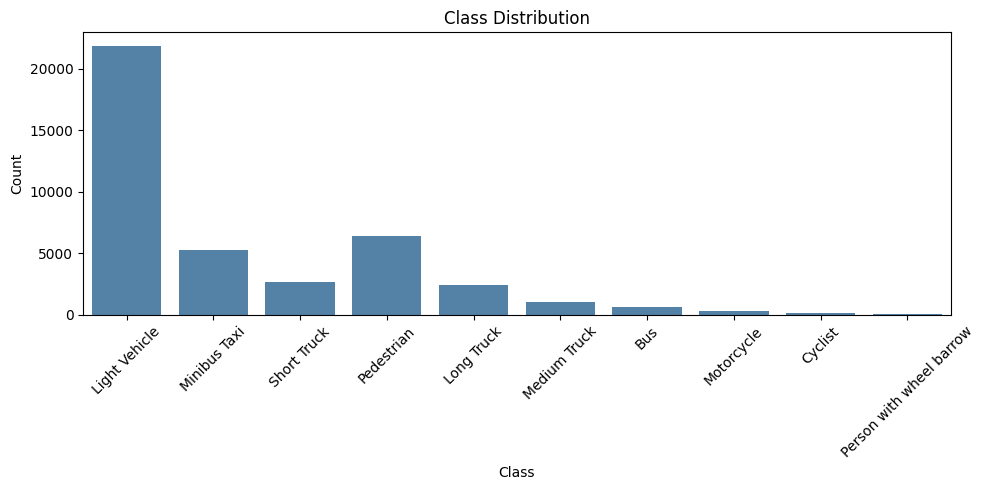

In [18]:
# Class Distribution Chart
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="class_name", color="steelblue")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

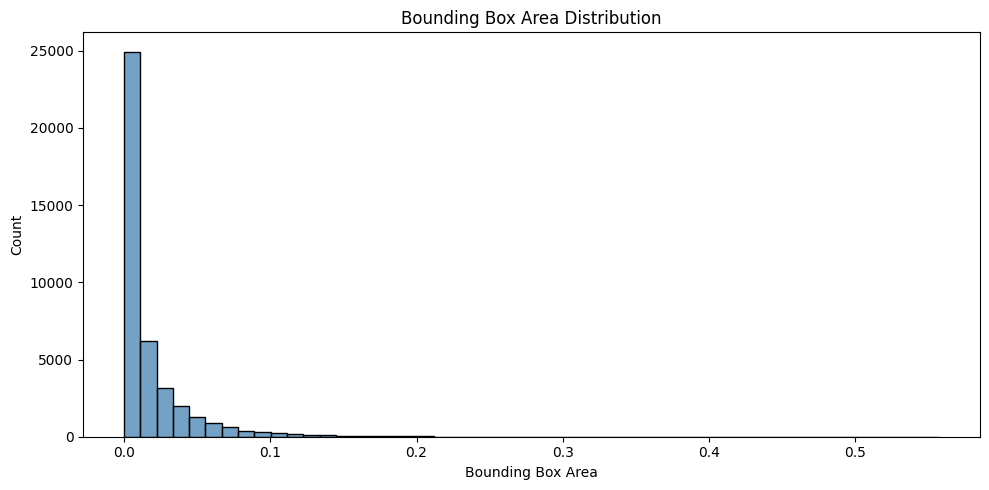

In [19]:
# Bounding Box Size Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["bbox_area"], bins=50, color="steelblue")
plt.title("Bounding Box Area Distribution")
plt.xlabel("Bounding Box Area")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

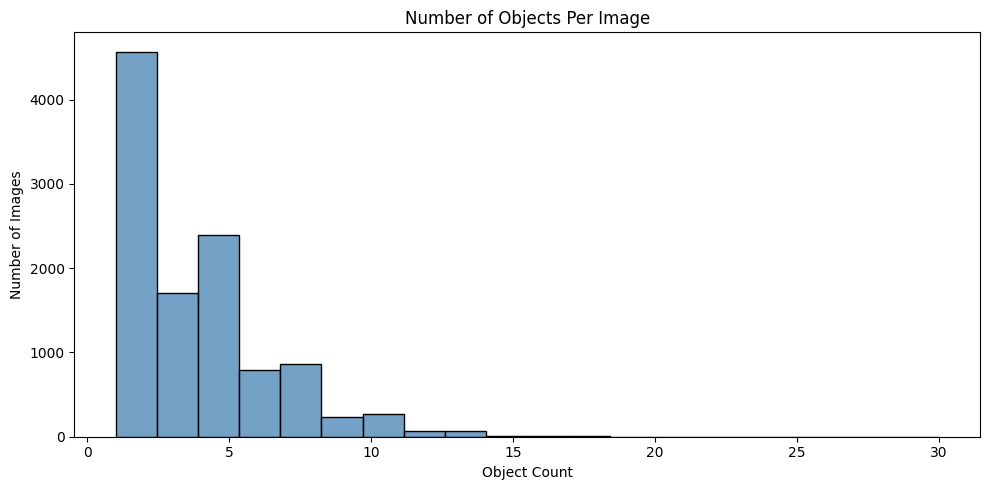

In [20]:
# Objects Per Image
objects_per_image = df.groupby("filename").size()

plt.figure(figsize=(10, 5))
sns.histplot(objects_per_image, bins=20, color="steelblue")
plt.title("Number of Objects Per Image")
plt.xlabel("Object Count")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

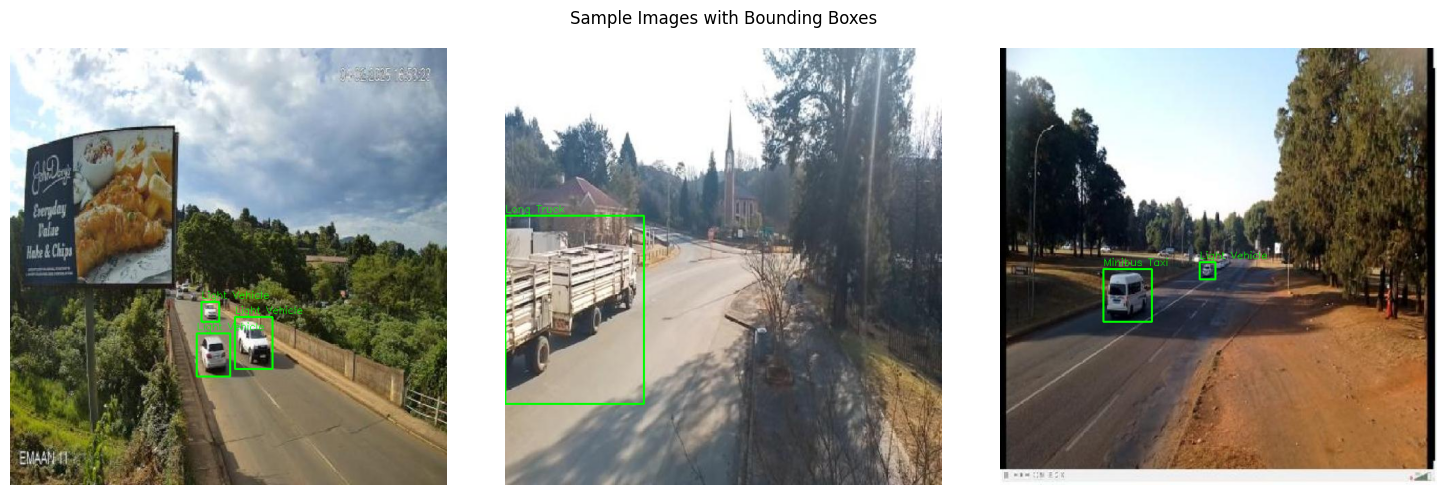

In [21]:
# Show Sample Images with Bounding Boxes
import cv2
import numpy as np
import random

def show_sample(image_dir, label_dir, class_names, n=3):
    image_files = list(Path(image_dir).glob("*.jpg"))
    samples = random.sample(image_files, n)

    fig, axes = plt.subplots(1, n, figsize=(15, 5))

    for ax, img_path in zip(axes, samples):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        label_path = Path(label_dir) / (img_path.stem + ".txt")
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls, x, y, bw, bh = map(float, parts)
                        x1 = int((x - bw/2) * w)
                        y1 = int((y - bh/2) * h)
                        x2 = int((x + bw/2) * w)
                        y2 = int((y + bh/2) * h)
                        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
                        cv2.putText(img, class_names[int(cls)], (x1, y1-5),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
        ax.imshow(img)
        ax.axis("off")

    plt.suptitle("Sample Images with Bounding Boxes")
    plt.tight_layout()
    plt.show()

show_sample(TRAIN_IMAGES, TRAIN_LABELS, CLASS_NAMES)